## Fishery CPUE data and model comparison

In [1]:
from pathlib import Path
from io import StringIO
import sys
import pygmt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, to_hex
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import ScaledTranslation
from matplotlib.legend_handler import HandlerBase
from scipy.stats import kurtosis, skew
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'utils.py').exists():
    raise FileNotFoundError('Run this notebook from the project root containing utils.py')
sys.path.insert(0, str(ROOT.resolve()))
import importlib
import utils as project_utils
importlib.reload(project_utils)
from utils import (load_fishery_data, distribution_diagnostics, make_year_holdout_split,
                   evaluate_baseline_family, load_penalized_dqr_bundle,
                   save_numeric_results, set_publication_style)

DATA_PATH = ROOT / 'data' / 'fishery_data' / 'Fishery_Env.csv'
RESULTS_DIR = ROOT / 'results'
FIGURE_DIR = ROOT / 'figure'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ROOT / 'models' / 'best_hmic_dqr.pt'
MODEL_CONFIG_PATH = ROOT / 'models' / 'best_hmic_dqr_config.json'
SEED = 42
INCLUDE_SPATIAL = False
set_publication_style()
plt.rcParams.update({
    'font.family': 'Times New Roman', 'mathtext.fontset': 'stix',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# Twelve-level discrete coolwarm palette used only by the manuscript figures.
COOLWARM_12 = [
    to_hex(plt.get_cmap('coolwarm', 12)(index)) for index in range(12)
]
FOUR_MODEL_COLORS = {
    model: COOLWARM_12[index]
    for model, index in zip(
        ('LQR', 'QRF', 'QXGBoost', 'HMIC-DQR'), (1, 4, 7, 10)
    )
}
DQR_FAMILY_COLORS = {
    model: COOLWARM_12[index]
    for model, index in zip(('DQR', 'MIC-DQR', 'HMIC-DQR'), (2, 6, 10))
}
DQR_FAMILY_COLORS['best-HMIC-DQR'] = DQR_FAMILY_COLORS['HMIC-DQR']

# Consistent marker/line semantics across all model-comparison figures.
FOUR_MODEL_STYLES = {
    model: dict(
        marker='s' if model == 'HMIC-DQR' else 'o',
        linestyle='-', linewidth=1.25, markersize=3.2,
    )
    for model in ('LQR', 'QRF', 'QXGBoost', 'HMIC-DQR')
}
DQR_FAMILY_STYLES = {
    model: dict(
        marker='s' if model in ('HMIC-DQR', 'best-HMIC-DQR') else 'o',
        linestyle='--', linewidth=1.25, markersize=3.2,
    )
    for model in ('DQR', 'MIC-DQR', 'HMIC-DQR', 'best-HMIC-DQR')
}


class _HandlerCenteredLineAboveBar(HandlerBase):
    """Draw one centered marker above a bar swatch under one shared label."""

    def create_artists(
            self, legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans):
        line_proxy, bar_proxy = orig_handle
        center_y = 0.20 * height - ydescent
        bar = Rectangle(
            (xdescent, center_y - 0.37 * height), width, 0.30 * height,
            facecolor=bar_proxy.get_facecolor(),
            edgecolor=bar_proxy.get_edgecolor(),
            linewidth=bar_proxy.get_linewidth(),
            alpha=bar_proxy.get_alpha(), transform=trans,
        )
        y_line = center_y + 0.22 * height
        line = Line2D(
            [xdescent, xdescent + width], [y_line, y_line],
            color=line_proxy.get_color(),
            linestyle=line_proxy.get_linestyle(),
            linewidth=line_proxy.get_linewidth(),
            marker=None, transform=trans,
        )
        marker = Line2D(
            [xdescent + 0.50 * width], [y_line],
            color=line_proxy.get_color(), linestyle='None',
            marker=line_proxy.get_marker(),
            markersize=line_proxy.get_markersize(),
            markerfacecolor=line_proxy.get_markerfacecolor(),
            markeredgecolor=line_proxy.get_markeredgecolor(),
            transform=trans,
        )
        return [bar, line, marker]


class _HandlerShiftedIdeal(HandlerBase):
    """Draw the Ideal line slightly lower without moving model markers."""

    def create_artists(
            self, legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans):
        y_line = 0.38 * height - ydescent
        line = Line2D(
            [xdescent, xdescent + width], [y_line, y_line],
            color=orig_handle.get_color(),
            linestyle=orig_handle.get_linestyle(),
            linewidth=orig_handle.get_linewidth(),
            marker=orig_handle.get_marker(),
            markersize=orig_handle.get_markersize(), transform=trans)
        return [line]


def lower_legend_text(legend, figure, offset_points=1.5):
    """Lower legend labels while leaving model handles unchanged."""
    offset = ScaledTranslation(
        0, -offset_points / 72, figure.dpi_scale_trans)
    for legend_text in legend.get_texts():
        legend_text.set_verticalalignment('center')
        legend_text.set_transform(legend_text.get_transform() + offset)

### Data and evaluation protocol

Observations from 2011–2018 constitute the development period and are divided within each calendar year and month group into 80% training and 20% validation subsets. All observations from 2019 form the temporal holdout used for model evaluation. Longitude and latitude are excluded from the model inputs. The predictors comprise six environmental variables and the cyclic month pair $\sin(2\pi m/12)$ and $\cos(2\pi m/12)$. The frozen HMIC-DQR is loaded without refitting.

,n,minimum,zero_fraction,mean,median,sd,p90,p95,p99,maximum,skewness,excess_kurtosis
0,8793,0.06,0.0,1.749506,1.479286,1.405389,3.322667,4.3452,7.0,14.78,2.468499,11.235884


ERROR 1: PROJ: proj_identify: /opt/miniconda3/envs/deepQFG/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: proj_identify: /opt/miniconda3/envs/deepQFG/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


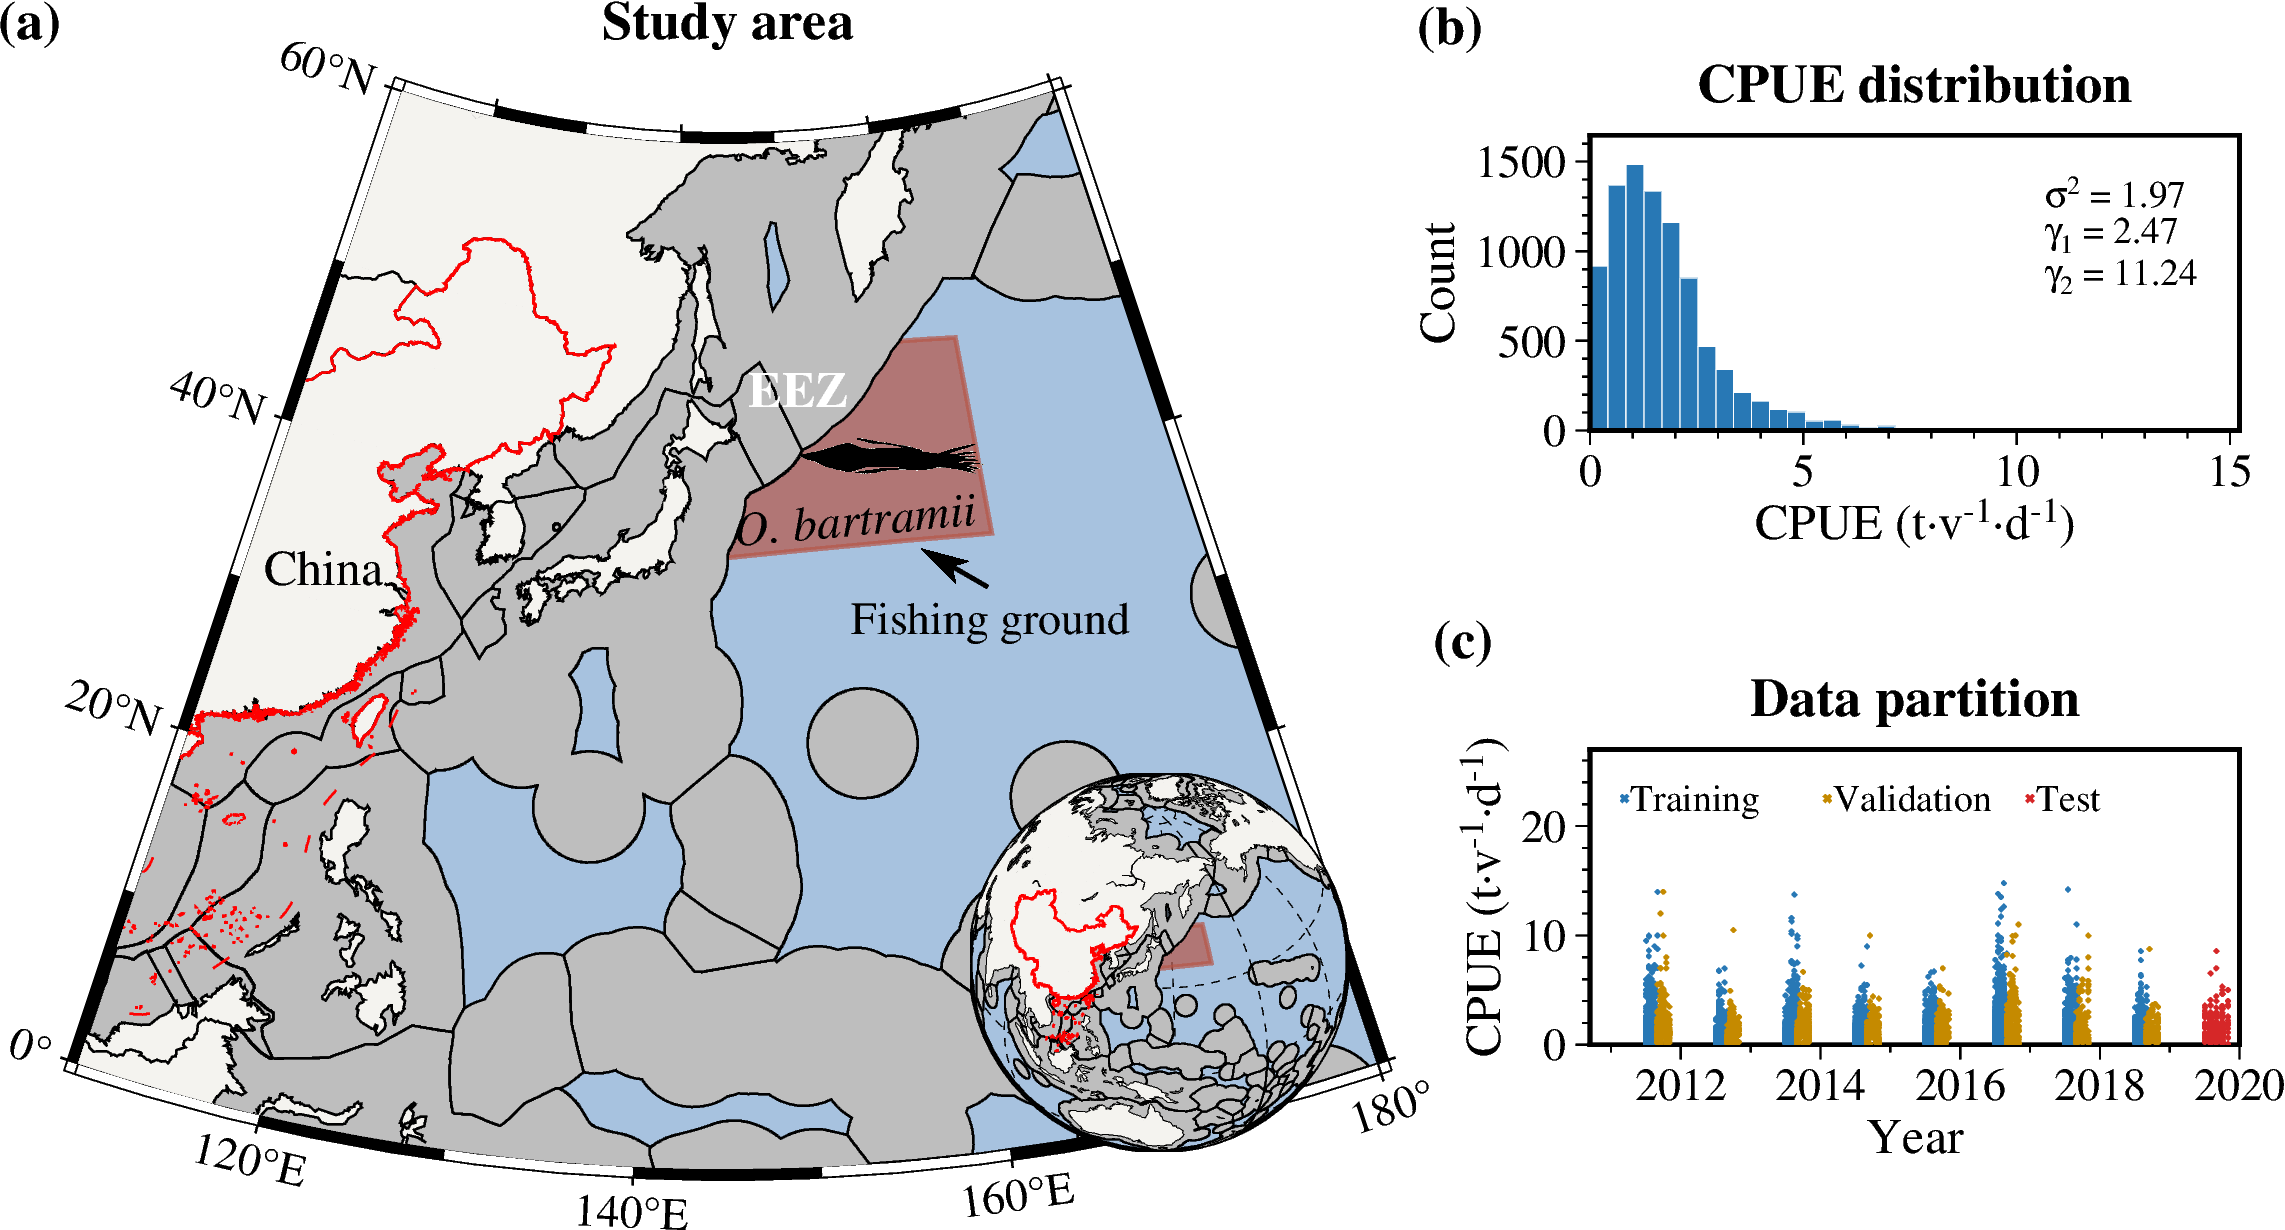

,subset,n,fraction of included data,years,calendar year and month groups,role
0,train,6771,0.770044,2011–2018,40,model fitting
1,validation,1696,0.192881,2011–2018,40,checkpoint selection
2,test,326,0.037075,2019,5,model evaluation


,feature,type
0,SST,environment
1,Chl-a,environment
2,MLT,environment
3,GH,environment
4,U,environment
5,V,environment
6,Month_sin,cyclic month
7,Month_cos,cyclic month


Rows=8,793; months=45; spatial cells=1,734


In [2]:
fishery, X, y, feature_names = load_fishery_data(
    DATA_PATH, include_spatial=INCLUDE_SPATIAL)
analysis_mask = fishery['YearMonth'].str[:4].astype(int).between(2011, 2019).to_numpy()
fishery = fishery.loc[analysis_mask].reset_index(drop=True)
X, y = X[analysis_mask], y[analysis_mask]
display(distribution_diagnostics(y))

year_month = fishery['YearMonth'].to_numpy()
split = make_year_holdout_split(
    year_month, development_years=range(2011, 2019),
    test_year=2019, seed=SEED, train_fraction=0.80)
observation_dates = pd.PeriodIndex(year_month, freq='M').to_timestamp()
decimal_year = observation_dates.year + (observation_dates.month - 1) / 12

map_assets = ROOT / 'data' / 'GMT_EEZ'
eez_vector_path = (map_assets / 'EEZ_land_union_v4_202410'
                   / 'EEZ_land_union_v4_202410.shp')
fg_coords = [[145, 36], [165, 36], [165, 48], [145, 48], [145, 36]]
bin_width = (float(np.max(y)) - float(np.min(y))) / 35
histogram_counts, _ = np.histogram(y, bins=35)
histogram_region = [0, float(np.max(y)) * 1.03, 0, int(histogram_counts.max() * 1.12)]

cpue_figure = pygmt.Figure()
with pygmt.config(
    FONT_ANNOT_PRIMARY='11p,Times-Roman,black',
    FONT_LABEL='12p,Times-Roman,black',
    FONT_TITLE='13p,Times-Bold,black',
    MAP_TITLE_OFFSET='-2p',
    MAP_FRAME_PEN='1p,black',
):
    cpue_figure.coast(
        region=[110, 180, 0, 60], projection='L145/42/0/60/11.0c',
        frame=['a20f10', 'WSne+tStudy area', 'x+lLongitude', 'y+lLatitude'],
        water='167/194/223', land='244/243/239',
        shorelines='1/0.5p', borders='1/0.5p', area_thresh=10000,
    )
    cpue_figure.text(
        x=77, y=54, text='(a)', font='13p,Times-Bold,black',
        justify='BR', no_clip=True,
    )
    cpue_figure.plot(
        data=fg_coords, pen='1p,181/86/72@30', fill='181/86/72@30')
    # Match the EEZ treatment used in 01_Data.ipynb, final Figure 2(b):
    # opaque grey fill, black outline, and a white bold label.
    cpue_figure.plot(
        data=eez_vector_path, pen='0.5p,black', fill='gray')
    cpue_figure.coast(
        land='244/243/239', shorelines='1/0.5p',
        borders='1/0.5p', area_thresh=10000)
    cpue_figure.text(
        x=151.0, y=46.0, text='EEZ',
        font='12p,Times-Bold,white', justify='CM')
    cpue_figure.text(
        x=164, y=31.8, text='Fishing ground',
        font='11p,Times-Roman,black', justify='TC',
    )
    cpue_figure.plot(
        x=[164], y=[32.8], direction=([150], [0.65]),
        style='v0.40c+e', pen='1p,black', fill='black',
    )
    cpue_figure.plot(data=map_assets / 'CN-border-L1.gmt', pen='0.5p,red')
    cpue_figure.text(x=115.5, y=32, text='China', font='12p,Times-Roman,black')
    cpue_figure.text(
        x=154.8, y=38, text='O. bartramii',
        font='11.5p,Times-Italic,black', angle=5,
    )
    cpue_figure.image(
        imagefile=map_assets / 'O.bartramii_mask.png',
        position='g150.5/40.4+w-1.6',
    )
    with pygmt.config(MAP_GRID_PEN_PRIMARY='0.25p,black,2_2'):
        with cpue_figure.inset(position='jBR+w3.2c+o0.25c/0.15c'):
            cpue_figure.coast(
                projection='G145/38/?', region='g', frame='g',
                water='167/194/223', land='244/243/239', shorelines='faint',
            )
            # Draw the fishing-ground overlay first so the opaque EEZ remains above it.
            cpue_figure.plot(
                data=[[145, 36, 165, 48]], style='r+s',
                pen='1p,181/86/72@30', fill='181/86/72@30',
            )
            # Add the same opaque EEZ band used in the main map, without a text label.
            cpue_figure.plot(
                data=eez_vector_path, pen='0.35p,black', fill='gray')
            # Redraw land and coastlines so the globe remains geographically legible.
            cpue_figure.coast(
                land='244/243/239', shorelines='faint', area_thresh=10000)
            cpue_figure.plot(data=map_assets / 'CN-border-L1.gmt', pen='0.5p,red')

    cpue_figure.shift_origin(xshift='12.8c', yshift='6.25c')
    with pygmt.config(MAP_TITLE_OFFSET='8p'):
        cpue_figure.histogram(
            data=y, series=bin_width, region=histogram_region,
            projection='X5.5c/2.5c', fill='#2878B5', pen='0.15p,white',
            frame=['WSrt+tCPUE distribution',
                   'xaf+lCPUE (t·v@+-1@+·d@+-1@+)', 'yaf+lCount'],
        )
    distribution_stats = [
        f'@~s@~@+2@+ = {np.var(y):.3g}',
        f'@~g@~@-1@- = {skew(y, bias=False):.2f}',
        f'@~g@~@-2@- = {kurtosis(y, fisher=True, bias=False):.2f}',
    ]
    for y_fraction, label in zip((0.86, 0.72, 0.58), distribution_stats):
        cpue_figure.text(
            x=histogram_region[1] * 0.70,
            y=histogram_region[3] * y_fraction,
            text=label, font='9p,Times-Roman,black', justify='TL',
        )
    cpue_figure.text(
        x=histogram_region[0] - 2.5, y=histogram_region[3] * 1.31,
        text='(b)', font='13p,Times-Bold,black',
        justify='BR', no_clip=True,
    )

    cpue_figure.shift_origin(yshift='-5.20c')
    split_region = [2010.7, 2020.0, 0, 27]
    with pygmt.config(MAP_TITLE_OFFSET='8p'):
        cpue_figure.basemap(
            region=split_region, projection='X5.5c/2.5c',
            frame=['WSrt+tData partition', 'xa2f1+lYear',
                   'yaf+lCPUE (t·v@+-1@+·d@+-1@+)'],
        )
    split_groups = {
        'Training': split['train'],
        'Validation': split['validation'],
        'Test': split['test'],
    }
    split_styles = {
        'Training': dict(style='x0.04c', pen='0.8p,#2878B5'),
        'Validation': dict(style='x0.04c', pen='0.8p,#C58A00'),
        'Test': dict(style='x0.04c', pen='0.8p,#D62728'),
    }
    # Compress the within-year month positions into two non-overlapping halves:
    # training on the left and validation on the right.
    year_part = np.floor(np.asarray(decimal_year))
    within_year = np.asarray(decimal_year) - year_part
    development_indices = np.concatenate([split['train'], split['validation']])
    season_min = within_year[development_indices].min()
    season_max = within_year[development_indices].max()
    season_mid = (season_min + season_max) / 2
    half_position = 0.5 * (within_year - season_min)
    group_x = {
        'Training': year_part + season_min + half_position,
        'Validation': year_part + season_mid + half_position,
        'Test': np.asarray(decimal_year),
    }
    for group_name, indices in split_groups.items():
        cpue_figure.plot(
            x=group_x[group_name][indices],
            y=y[indices], **split_styles[group_name],
        )
    cpue_figure.text(
        x=split_region[0] - 1.39, y=split_region[3] * 1.31,
        text='(c)', font='13p,Times-Bold,black',
        justify='BR', no_clip=True,
    )
    with pygmt.config(FONT_ANNOT_PRIMARY='9p,Times-Roman,black'):
        split_legend = StringIO(
            'N 3\n'
            'S 0.03c x 0.08c - 0.8p,#2878B5 0.08c Training\n'
            'S 0.03c x 0.08c - 0.8p,#C58A00 0.08c Validation\n'
            'S 0.03c x 0.08c - 0.8p,#D62728 0.08c Test\n'
        )
        cpue_figure.legend(
            spec=split_legend,
            position='jTL+o0.12c/0.10c+w5.15c',
        )

cpue_figure.show()
cpue_figure.savefig(FIGURE_DIR / 'Fig_02.png', dpi=600)
cpue_figure.savefig(FIGURE_DIR / 'Fig_02.pdf')

split_table = pd.DataFrame({
    'subset': ['train', 'validation', 'test'],
    'n': [len(split['train']), len(split['validation']), len(split['test'])],
    'fraction of included data': [len(split[name]) / len(y) for name in ('train', 'validation', 'test')],
    'years': ['2011–2018', '2011–2018', '2019'],
    'calendar year and month groups': [len(np.unique(year_month[split[name]])) for name in ('train', 'validation', 'test')],
    'role': ['model fitting', 'checkpoint selection', 'model evaluation'],
})
display(split_table)
feature_type = {name: ('cyclic month' if name.startswith('Month_')
                       else 'space' if name in ('Lon', 'Lat')
                       else 'environment') for name in feature_names}
display(pd.DataFrame({'feature': feature_names,
                      'type': [feature_type[name] for name in feature_names]}))
print(f'Rows={len(y):,}; months={fishery.YearMonth.nunique()}; ' +
      f'spatial cells={fishery.groupby(["Lon", "Lat"]).ngroups:,}')